# 11 -- Vol Model Shootout

**Same data, same frequency, same position sizing, different models.**

Tests 4 vol prediction models on the daily macro_strategy dataset:
1. **XGBoost** — gradient boosted trees (our current best)
2. **AR** — autoregressive on trailing realized vol
3. **HAR-RV** — Heterogeneous Autoregressive (1d, 5d, 21d trailing vol)
4. **Ridge** — linear regression on all 210 features

All use:
- 20d forward realized vol as target
- Expanding window, monthly retraining (21 days)
- 60-day embargo
- Same vol-targeting backtest: exposure = target_vol / predicted_vol, clamped [0.25, 1.5]

If AR or HAR-RV beat XGBoost here, it means the model matters less than the frequency. If XGBoost wins, it means the 210 features add genuine value over simple vol persistence.

**If simpler models work at daily frequency, MPTE (transformer) is worth testing next.**

In [2]:
import pandas as pd
import numpy as np
import os, sys, time
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.ar_model import AutoReg
import warnings
warnings.filterwarnings('ignore')

# Repointed 2026-07-12: this repo is self-contained — the merged panel is built by
# 01->03 into ./data/processed (populate via setup_data.py or by running them).
MACRO_STRATEGY_DIR = os.path.dirname(os.path.abspath('__file__'))

P3_DATA_DIR = os.path.join(MACRO_STRATEGY_DIR, 'data', 'raw')  # was an external Downloads path

PROCESSED_DIR = os.path.join(MACRO_STRATEGY_DIR, 'data', 'processed')

merged = pd.read_csv(os.path.join(PROCESSED_DIR, 'merged_dataset.csv'),
                      parse_dates=['date'], index_col='date')
merged = merged[~merged.index.duplicated(keep='first')]
for col in ['fwd_vol', 'regime_label']:
    if col in merged.columns:
        merged = merged.drop(columns=[col])

exclude_cols = ['sprtrn', 'spindx']
feature_cols = [c for c in merged.columns if c not in exclude_cols]
X_all = merged[feature_cols].ffill().fillna(0)

X_np = X_all.values.astype(np.float32)
dates = X_all.index.values
spy_returns = merged['sprtrn'].values

print(f"Loaded: {merged.shape}")
print(f"Features: {X_np.shape}")

Loaded: (8047, 212)
Features: (8047, 210)


In [3]:
def compute_forward_vol(returns_np, window):
    n = len(returns_np)
    fwd_vol = np.full(n, np.nan)
    for i in range(n - window):
        fwd_vol[i] = np.std(returns_np[i:i+window], ddof=1) * np.sqrt(252)
    return fwd_vol

FWD_WINDOW = 20
fwd_vol = compute_forward_vol(spy_returns, FWD_WINDOW)
print(f"20d forward vol: mean={np.nanmean(fwd_vol):.3f}, valid={(~np.isnan(fwd_vol)).sum()}")

20d forward vol: mean=0.157, valid=8027


In [4]:
# ============================================================
# Model 1: XGBoost (uses all 210 features)
# ============================================================

def expanding_xgboost(X_np, y_np, min_train=504, retrain_every=21, embargo=60):
    n = len(X_np)
    valid_mask = ~np.isnan(y_np)
    pred_out = np.full(n, np.nan)
    models_trained = 0
    
    for retrain_idx in range(min_train, n, retrain_every):
        train_end = retrain_idx - embargo
        if train_end < 100:
            continue
        
        train_valid = valid_mask[:train_end]
        tr_pos = np.where(train_valid)[0]
        if len(tr_pos) < 100:
            continue
        
        Xtr = X_np[tr_pos]
        ytr = y_np[tr_pos]
        
        test_end = min(retrain_idx + retrain_every, n)
        te_pos = np.arange(retrain_idx, test_end)
        Xte = X_np[te_pos]
        
        model = xgb.XGBRegressor(
            objective='reg:squarederror', n_estimators=200, max_depth=5,
            learning_rate=0.05, subsample=0.8, colsample_bytree=0.6,
            min_child_weight=50, reg_alpha=1.0, reg_lambda=2.0,
            random_state=42, verbosity=0
        )
        model.fit(Xtr, ytr)
        pred = np.clip(model.predict(Xte), 0.03, 1.0)
        
        for j, pos in enumerate(te_pos):
            if np.isnan(pred_out[pos]):
                pred_out[pos] = pred[j]
        models_trained += 1
    
    return pred_out, models_trained


# ============================================================
# Model 2: AR on trailing realized vol
# ============================================================

def expanding_ar(spy_returns, fwd_vol, min_train=504, retrain_every=21, embargo=60):
    n = len(spy_returns)
    trailing_vol = pd.Series(spy_returns).rolling(20).std().values * np.sqrt(252)
    pred_out = np.full(n, np.nan)
    models_trained = 0
    
    for retrain_idx in range(min_train, n, retrain_every):
        train_end = retrain_idx - embargo
        if train_end < 100:
            continue
        
        vol_train = trailing_vol[:train_end]
        valid = ~np.isnan(vol_train)
        vol_clean = vol_train[valid]
        
        if len(vol_clean) < 50:
            continue
        
        try:
            best_bic, best_lag = np.inf, 1
            for lag in range(1, min(11, len(vol_clean) // 3)):
                try:
                    ar = AutoReg(vol_clean, lags=lag).fit()
                    if ar.bic < best_bic:
                        best_bic, best_lag = ar.bic, lag
                except:
                    pass
            
            ar_model = AutoReg(vol_clean, lags=best_lag).fit()
            ar_pred = np.clip(ar_model.forecast(1)[0], 0.03, 1.0)
        except:
            ar_pred = np.nanmean(vol_clean[-60:])
        
        test_end = min(retrain_idx + retrain_every, n)
        for pos in range(retrain_idx, test_end):
            if np.isnan(pred_out[pos]):
                pred_out[pos] = ar_pred
        models_trained += 1
    
    return pred_out, models_trained


# ============================================================
# Model 3: HAR-RV (1d, 5d, 21d trailing vol -> forward vol)
# ============================================================

def expanding_har(spy_returns, fwd_vol, min_train=504, retrain_every=21, embargo=60):
    n = len(spy_returns)
    rv_1d = np.abs(spy_returns) * np.sqrt(252)
    rv_5d = pd.Series(spy_returns).rolling(5).std().values * np.sqrt(252)
    rv_21d = pd.Series(spy_returns).rolling(21).std().values * np.sqrt(252)
    
    pred_out = np.full(n, np.nan)
    models_trained = 0
    
    for retrain_idx in range(min_train, n, retrain_every):
        train_end = retrain_idx - embargo
        if train_end < 100:
            continue
        
        X_har = np.column_stack([rv_1d[:train_end], rv_5d[:train_end], rv_21d[:train_end]])
        y_har = fwd_vol[:train_end]
        
        valid = ~(np.isnan(X_har).any(axis=1) | np.isnan(y_har))
        X_clean = X_har[valid]
        y_clean = y_har[valid]
        
        if len(X_clean) < 50:
            continue
        
        try:
            har_model = LinearRegression().fit(X_clean, y_clean)
        except:
            continue
        
        test_end = min(retrain_idx + retrain_every, n)
        for pos in range(retrain_idx, test_end):
            x_now = np.array([[rv_1d[pos], rv_5d[pos], rv_21d[pos]]])
            if np.isnan(x_now).any():
                continue
            if np.isnan(pred_out[pos]):
                pred_out[pos] = np.clip(har_model.predict(x_now)[0], 0.03, 1.0)
        models_trained += 1
    
    return pred_out, models_trained


# ============================================================
# Model 4: Ridge regression (all 210 features, regularized)
# ============================================================

def expanding_ridge(X_np, y_np, min_train=504, retrain_every=21, embargo=60):
    n = len(X_np)
    valid_mask = ~np.isnan(y_np)
    pred_out = np.full(n, np.nan)
    models_trained = 0
    
    for retrain_idx in range(min_train, n, retrain_every):
        train_end = retrain_idx - embargo
        if train_end < 100:
            continue
        
        train_valid = valid_mask[:train_end]
        tr_pos = np.where(train_valid)[0]
        if len(tr_pos) < 100:
            continue
        
        Xtr = X_np[tr_pos]
        ytr = y_np[tr_pos]
        
        scaler = StandardScaler()
        Xtr_sc = scaler.fit_transform(Xtr)
        
        model = Ridge(alpha=10.0).fit(Xtr_sc, ytr)
        
        test_end = min(retrain_idx + retrain_every, n)
        te_pos = np.arange(retrain_idx, test_end)
        Xte_sc = scaler.transform(X_np[te_pos])
        pred = np.clip(model.predict(Xte_sc), 0.03, 1.0)
        
        for j, pos in enumerate(te_pos):
            if np.isnan(pred_out[pos]):
                pred_out[pos] = pred[j]
        models_trained += 1
    
    return pred_out, models_trained

print("All 4 model engines ready.")

All 4 model engines ready.


In [5]:
# ============================================================
# Run all 4 models
# ============================================================

model_preds = {}

print("Running XGBoost...")
t0 = time.time()
xgb_pred, xgb_n = expanding_xgboost(X_np, fwd_vol)
print(f"  {xgb_n} models, {(~np.isnan(xgb_pred)).sum()} predictions, {time.time()-t0:.0f}s")
model_preds['XGBoost'] = xgb_pred

print("\nRunning AR...")
t0 = time.time()
ar_pred, ar_n = expanding_ar(spy_returns, fwd_vol)
print(f"  {ar_n} models, {(~np.isnan(ar_pred)).sum()} predictions, {time.time()-t0:.0f}s")
model_preds['AR'] = ar_pred

print("\nRunning HAR-RV...")
t0 = time.time()
har_pred, har_n = expanding_har(spy_returns, fwd_vol)
print(f"  {har_n} models, {(~np.isnan(har_pred)).sum()} predictions, {time.time()-t0:.0f}s")
model_preds['HAR-RV'] = har_pred

print("\nRunning Ridge...")
t0 = time.time()
ridge_pred, ridge_n = expanding_ridge(X_np, fwd_vol)
print(f"  {ridge_n} models, {(~np.isnan(ridge_pred)).sum()} predictions, {time.time()-t0:.0f}s")
model_preds['Ridge'] = ridge_pred

print("\nAll models complete.")

Running XGBoost...
  360 models, 7543 predictions, 582s

Running AR...
  360 models, 7543 predictions, 24s

Running HAR-RV...
  360 models, 7543 predictions, 1s

Running Ridge...
  360 models, 7543 predictions, 16s

All models complete.


In [6]:
# ============================================================
# Prediction quality comparison
# ============================================================

print("=" * 70)
print("VOL PREDICTION QUALITY -- 4 MODELS ON SAME DAILY DATA")
print("=" * 70)

print(f"\n{'Model':<12} {'R²':>8} {'Corr':>8} {'MAE':>8} {'RMSE':>8} {'Days':>8}")
print("-" * 55)

quality = {}

for name, pred in model_preds.items():
    both = (~np.isnan(pred)) & (~np.isnan(fwd_vol))
    if both.sum() < 50:
        print(f"{name:<12} insufficient data ({both.sum()} days)")
        continue
    
    y_t = fwd_vol[both]
    y_p = pred[both]
    
    r2 = r2_score(y_t, y_p)
    corr = np.corrcoef(y_t, y_p)[0, 1]
    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    
    print(f"{name:<12} {r2:>8.4f} {corr:>8.4f} {mae:>8.4f} {rmse:>8.4f} {both.sum():>8}")
    
    quality[name] = {'r2': r2, 'corr': corr, 'mae': mae, 'rmse': rmse}

VOL PREDICTION QUALITY -- 4 MODELS ON SAME DAILY DATA

Model              R²     Corr      MAE     RMSE     Days
-------------------------------------------------------
XGBoost        0.2503   0.5042   0.0537   0.0875     7523
AR            -0.4566   0.2662   0.0728   0.1220     7523
HAR-RV         0.5076   0.7152   0.0446   0.0709     7523
Ridge         -3.7114   0.1863   0.1413   0.2193     7523


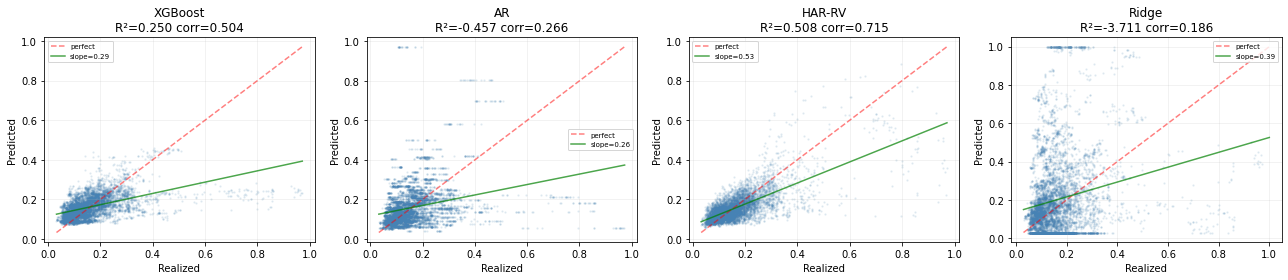

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, (name, pred) in enumerate(model_preds.items()):
    both = (~np.isnan(pred)) & (~np.isnan(fwd_vol))
    y_t = fwd_vol[both]
    y_p = pred[both]
    
    axes[i].scatter(y_t, y_p, alpha=0.1, s=2, color='steelblue')
    lims = [min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())]
    axes[i].plot(lims, lims, 'r--', alpha=0.5, label='perfect')
    z = np.polyfit(y_t, y_p, 1)
    axes[i].plot(lims, np.polyval(z, lims), 'g-', alpha=0.7, label=f'slope={z[0]:.2f}')
    
    q = quality.get(name, {})
    axes[i].set_title(f'{name}\nR²={q.get("r2",0):.3f} corr={q.get("corr",0):.3f}')
    axes[i].set_xlabel('Realized')
    axes[i].set_ylabel('Predicted')
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# Vol-targeting backtest -- all 4 models, same sizing
# ============================================================

TARGET_VOL = 0.15
MIN_EXP = 0.25
MAX_EXP = 1.50

def sharpe(r):
    return np.sqrt(252) * np.mean(r) / np.std(r) if np.std(r) > 0 else 0
def max_dd(c):
    return np.min((c - np.maximum.accumulate(c)) / np.maximum.accumulate(c))
def cagr(c):
    yrs = len(c) / 252
    return c[-1] ** (1/yrs) - 1 if yrs > 0 else 0

print("=" * 95)
print("VOL-TARGETING BACKTEST -- 4 MODELS, SAME SIZING")
print("=" * 95)
print(f"Target vol: {TARGET_VOL:.0%} | Exposure: [{MIN_EXP:.0%}, {MAX_EXP:.0%}]")

print(f"\n{'Model':<12} {'SPY Sh':>8} {'VT Sh':>8} {'Impr':>8} {'SPY DD':>8} {'VT DD':>8} "
      f"{'DD Impr':>8} {'SPY CAGR':>9} {'VT CAGR':>9} {'Exposure':>9}")
print("-" * 100)

bt_results = {}

for name, pred in model_preds.items():
    valid = ~np.isnan(pred)
    v_dates = dates[valid]
    v_spy = spy_returns[valid]
    v_pred = pred[valid]
    
    exposure = np.clip(TARGET_VOL / v_pred, MIN_EXP, MAX_EXP)
    exp_lagged = np.roll(exposure, 1)
    exp_lagged[0] = 1.0
    
    vt_ret = v_spy * exp_lagged
    spy_cum = np.cumprod(1 + v_spy)
    vt_cum = np.cumprod(1 + vt_ret)
    
    spy_sh = sharpe(v_spy)
    vt_sh = sharpe(vt_ret)
    spy_d = max_dd(spy_cum)
    vt_d = max_dd(vt_cum)
    spy_c = cagr(spy_cum)
    vt_c = cagr(vt_cum)
    avg_exp = np.mean(exp_lagged)
    
    print(f"{name:<12} {spy_sh:>8.3f} {vt_sh:>8.3f} {vt_sh-spy_sh:>+8.3f} "
          f"{spy_d:>7.1%} {vt_d:>7.1%} {vt_d-spy_d:>+7.1%} "
          f"{spy_c:>8.1%} {vt_c:>8.1%} {avg_exp:>8.1%}")
    
    bt_results[name] = {
        'dates': v_dates, 'spy_cum': spy_cum, 'vt_cum': vt_cum,
        'spy_returns': v_spy, 'vt_returns': vt_ret,
        'exposure': exp_lagged,
        'spy_sharpe': spy_sh, 'vt_sharpe': vt_sh,
        'spy_maxdd': spy_d, 'vt_maxdd': vt_d,
        'spy_cagr': spy_c, 'vt_cagr': vt_c,
        'avg_exposure': avg_exp,
    }

VOL-TARGETING BACKTEST -- 4 MODELS, SAME SIZING
Target vol: 15% | Exposure: [25%, 150%]

Model          SPY Sh    VT Sh     Impr   SPY DD    VT DD  DD Impr  SPY CAGR   VT CAGR  Exposure
----------------------------------------------------------------------------------------------------
XGBoost         0.544    0.620   +0.077  -56.8%  -45.6%  +11.2%     8.8%     9.0%   101.3%
AR              0.544    0.610   +0.067  -56.8%  -45.8%  +11.0%     8.8%    10.6%   108.2%
HAR-RV          0.544    0.654   +0.111  -56.8%  -50.5%   +6.3%     8.8%     9.5%   108.2%
Ridge           0.544    0.601   +0.057  -56.8%  -64.6%   -7.9%     8.8%    10.3%   102.5%


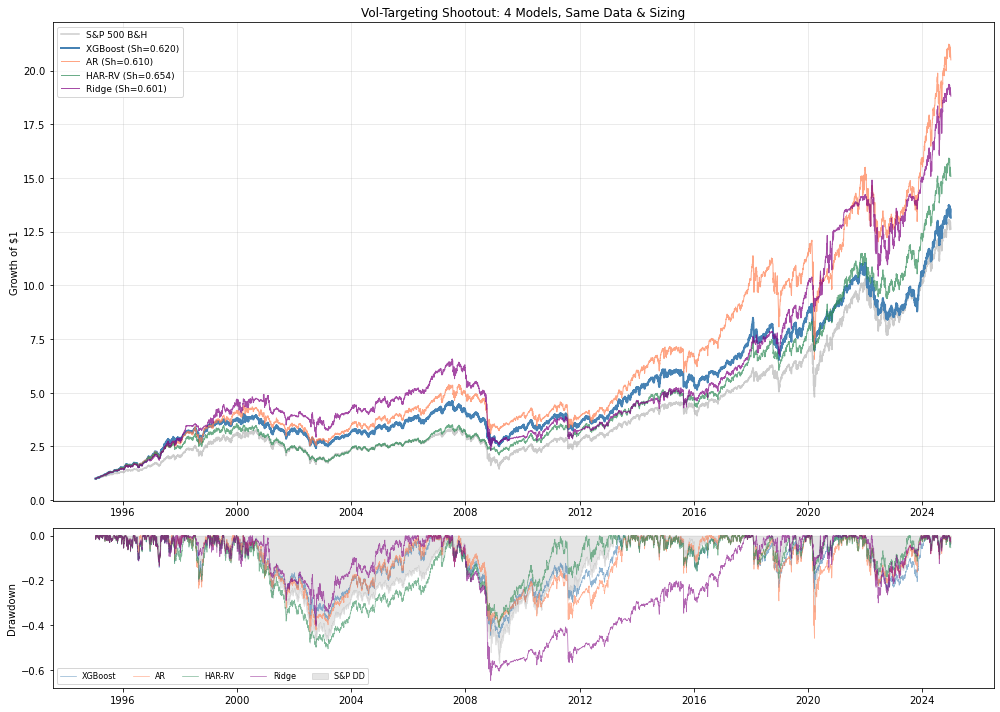

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

colors = {'XGBoost': 'steelblue', 'AR': 'coral', 'HAR-RV': 'seagreen', 'Ridge': 'purple'}

# Plot SPY once
first = list(bt_results.values())[0]
axes[0].plot(first['dates'], first['spy_cum'], label='S&P 500 B&H', color='gray', alpha=0.4)

for name, bt in bt_results.items():
    lw = 2.0 if name == 'XGBoost' else 1.0
    alpha = 1.0 if name == 'XGBoost' else 0.7
    axes[0].plot(bt['dates'], bt['vt_cum'],
                  label=f'{name} (Sh={bt["vt_sharpe"]:.3f})',
                  color=colors[name], linewidth=lw, alpha=alpha)

axes[0].set_title('Vol-Targeting Shootout: 4 Models, Same Data & Sizing')
axes[0].set_ylabel('Growth of $1')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Drawdown for all
for name, bt in bt_results.items():
    dd = (bt['vt_cum'] - np.maximum.accumulate(bt['vt_cum'])) / np.maximum.accumulate(bt['vt_cum'])
    axes[1].plot(bt['dates'], dd, color=colors[name], alpha=0.6, linewidth=0.7, label=name)

axes[1].fill_between(first['dates'],
    (first['spy_cum'] - np.maximum.accumulate(first['spy_cum'])) / np.maximum.accumulate(first['spy_cum']),
    0, color='gray', alpha=0.2, label='S&P DD')
axes[1].set_ylabel('Drawdown')
axes[1].legend(fontsize=8, ncol=5)

plt.tight_layout()
plt.show()

In [10]:
crises = {
    'Dot-com (2000-02)': ('2000-03-01', '2002-10-01'),
    'GFC (2007-09)':     ('2007-10-01', '2009-03-01'),
    'Euro crisis (2011)':('2011-07-01', '2011-10-01'),
    'China/Oil (2015)':  ('2015-08-01', '2016-02-01'),
    'COVID (2020)':      ('2020-02-01', '2020-04-01'),
    'Rate hikes (2022)': ('2022-01-01', '2022-10-01'),
}

print(f"{'Crisis':<25}", end="")
for name in bt_results:
    print(f" {name:>10}", end="")
print(f" {'S&P':>10}")
print("-" * (25 + 11 * (len(bt_results) + 1)))

for crisis_name, (start, end) in crises.items():
    print(f"{crisis_name:<25}", end="")
    spy_printed = False
    for name, bt in bt_results.items():
        bt_dates = pd.DatetimeIndex(bt['dates'])
        mask = (bt_dates >= start) & (bt_dates <= end)
        if mask.sum() < 5:
            print(f" {'n/a':>10}", end="")
            continue
        f = np.prod(1 + bt['vt_returns'][mask]) - 1
        print(f" {f:>9.1%}", end="")
        if not spy_printed:
            s = np.prod(1 + bt['spy_returns'][mask]) - 1
            spy_printed = True
    if spy_printed:
        print(f" {s:>9.1%}")
    else:
        print()

Crisis                       XGBoost         AR     HAR-RV      Ridge        S&P
--------------------------------------------------------------------------------
Dot-com (2000-02)            -28.1%    -30.8%    -42.2%    -20.5%    -37.9%
GFC (2007-09)                -40.9%    -37.1%    -36.1%    -57.8%    -51.9%
Euro crisis (2011)           -15.5%    -19.4%    -13.6%    -23.0%    -14.3%
China/Oil (2015)             -10.2%     -7.2%     -9.0%     -7.2%     -7.8%
COVID (2020)                 -15.9%    -34.1%    -10.2%    -10.7%    -23.4%
Rate hikes (2022)            -23.2%    -20.3%    -17.7%    -21.4%    -24.8%


In [11]:
# ============================================================
# Final ranking
# ============================================================

print("=" * 80)
print("FINAL RANKING BY SHARPE IMPROVEMENT")
print("=" * 80)

ranking = sorted(bt_results.items(), key=lambda x: x[1]['vt_sharpe'] - x[1]['spy_sharpe'], reverse=True)

print(f"\n{'Rank':<6} {'Model':<12} {'Sharpe Impr':>12} {'VT Sharpe':>10} {'VT CAGR':>9} {'VT MaxDD':>9} {'R²':>8}")
print("-" * 70)

for rank, (name, bt) in enumerate(ranking, 1):
    impr = bt['vt_sharpe'] - bt['spy_sharpe']
    q = quality.get(name, {})
    print(f"{rank:<6} {name:<12} {impr:>+12.3f} {bt['vt_sharpe']:>10.3f} "
          f"{bt['vt_cagr']:>8.1%} {bt['vt_maxdd']:>8.1%} {q.get('r2', 0):>8.3f}")

best_name = ranking[0][0]
print(f"\nBest model: {best_name}")

if best_name != 'XGBoost':
    print(f"\nSURPRISE: {best_name} beats XGBoost at daily frequency!")
    print(f"This means the 210 features don't add value over simple vol persistence.")
    print(f"Consider testing MPTE (transformer) next — if simple models work,")
    print(f"a transformer on the same daily data could work even better.")
else:
    print(f"\nXGBoost wins — the 210 macro features add genuine value")
    print(f"over simple vol persistence models (AR, HAR-RV).")
    print(f"MPTE might still be worth testing if you want to push further.")

FINAL RANKING BY SHARPE IMPROVEMENT

Rank   Model         Sharpe Impr  VT Sharpe   VT CAGR  VT MaxDD       R²
----------------------------------------------------------------------
1      HAR-RV             +0.111      0.654     9.5%   -50.5%    0.508
2      XGBoost            +0.077      0.620     9.0%   -45.6%    0.250
3      AR                 +0.067      0.610    10.6%   -45.8%   -0.457
4      Ridge              +0.057      0.601    10.3%   -64.6%   -3.711

Best model: HAR-RV

SURPRISE: HAR-RV beats XGBoost at daily frequency!
This means the 210 features don't add value over simple vol persistence.
Consider testing MPTE (transformer) next — if simple models work,
a transformer on the same daily data could work even better.
